In [7]:
# STEP 1: Import Libraries

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pickle


In [8]:
## STEP 2: Load Dataset
df = pd.read_csv("diabetes_cleaned.csv")

print(df.head())

print(df.shape)

print(df.columns)

print(df.info())


   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
(96146, 9)
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96146 entries, 0 to 96145
Data columns (total 9 columns):
 # 

In [9]:
## STEP 3: Data Cleaning
print(df.isnull().sum())

print(df.duplicated().sum())

df = df.drop_duplicates()


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
0


In [10]:
## STEP 4: Encode Categorical Columns
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

df['smoking_history'] = le.fit_transform(df['smoking_history'])


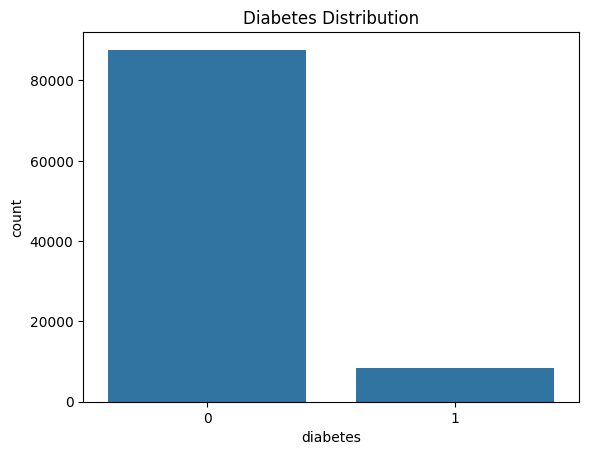

In [11]:
## STEP 5: EDA
### Diabetes Distribution
sns.countplot(x='diabetes', data=df)

plt.title("Diabetes Distribution")

plt.show()


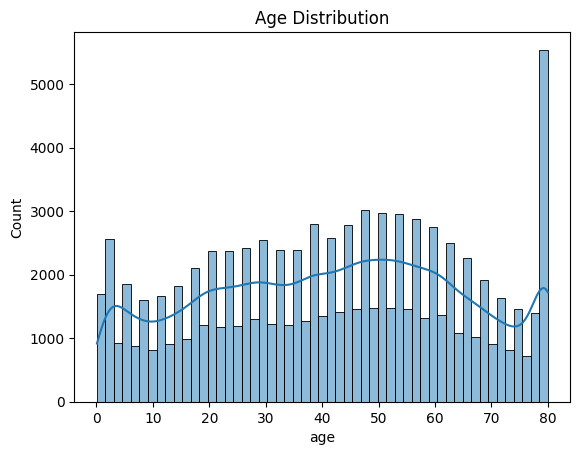

In [12]:
### Age Distribution
sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")

plt.show()


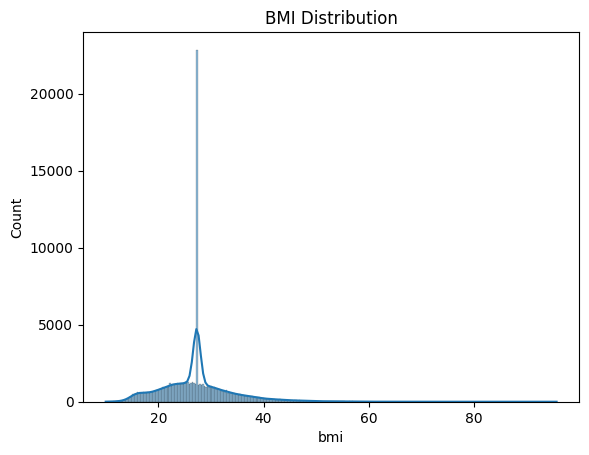

In [13]:
### BMI Distribution
sns.histplot(df['bmi'], kde=True)

plt.title("BMI Distribution")

plt.show()


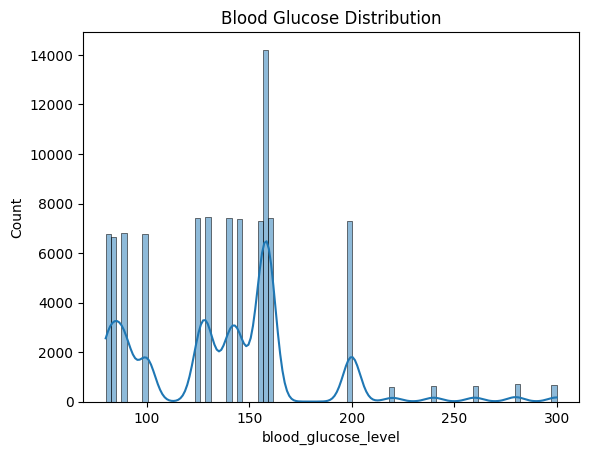

In [14]:
### Blood Glucose Level
sns.histplot(df['blood_glucose_level'], kde=True)

plt.title("Blood Glucose Distribution")

plt.show()


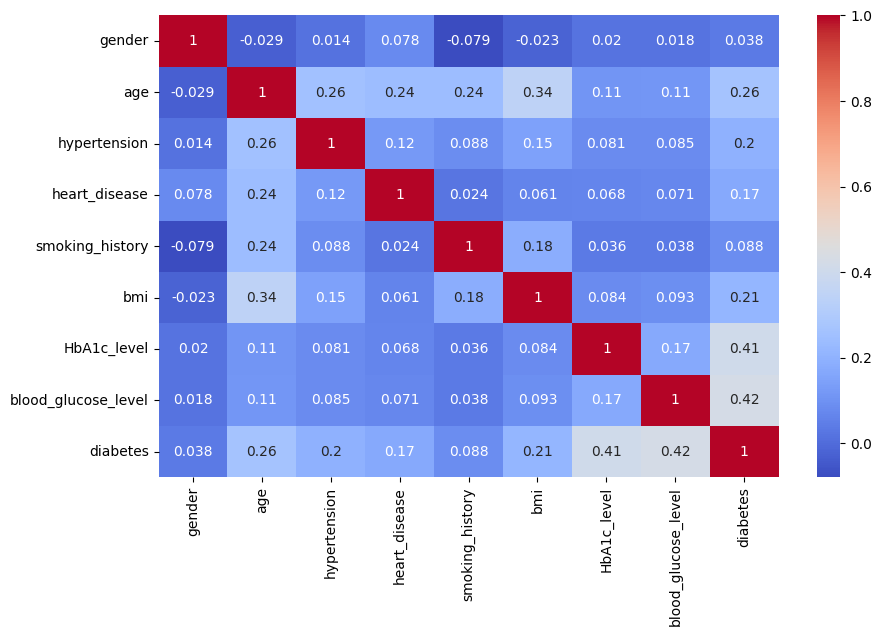

In [15]:
### Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()


In [16]:
## STEP 6: Feature Selection
X = df.drop('diabetes', axis=1)

y = df['diabetes']


In [17]:
## STEP 7: Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [18]:
## STEP 8: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)


In [19]:
## STEP 9: Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [20]:
## STEP 10: Decision Tree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [21]:
## STEP 11: Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [22]:
## STEP 12: Compare Models
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [

        accuracy_score(y_test, y_pred_lr),

        accuracy_score(y_test, y_pred_dt),

        accuracy_score(y_test, y_pred_rf)

    ],

    'Precision': [

        precision_score(y_test, y_pred_lr),

        precision_score(y_test, y_pred_dt),

        precision_score(y_test, y_pred_rf)

    ],

    'Recall': [

        recall_score(y_test, y_pred_lr),

        recall_score(y_test, y_pred_dt),

        recall_score(y_test, y_pred_rf)

    ],

    'F1 Score': [

        f1_score(y_test, y_pred_lr),

        f1_score(y_test, y_pred_dt),

        f1_score(y_test, y_pred_rf)

    ]

})

print(results)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.956942   0.854647  0.625218  0.722148
1        Decision Tree  0.947114   0.694260  0.730970  0.712143
2        Random Forest  0.968851   0.948800  0.689134  0.798384


In [23]:
## STEP 13: Best Model
best_model = results.loc[
    results['F1 Score'].idxmax()
]

print(best_model)


Model        Random Forest
Accuracy          0.968851
Precision           0.9488
Recall            0.689134
F1 Score          0.798384
Name: 2, dtype: object


In [24]:
## STEP 14: Random Forest Evaluation
print(confusion_matrix(
    y_test,
    y_pred_rf
))

print(classification_report(
    y_test,
    y_pred_rf
))


[[17445    64]
 [  535  1186]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.95      0.69      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



               Feature  Importance
6          HbA1c_level    0.389074
7  blood_glucose_level    0.328339
5                  bmi    0.120881
1                  age    0.101544
4      smoking_history    0.028572
2         hypertension    0.015087
3        heart_disease    0.009535
0               gender    0.006968


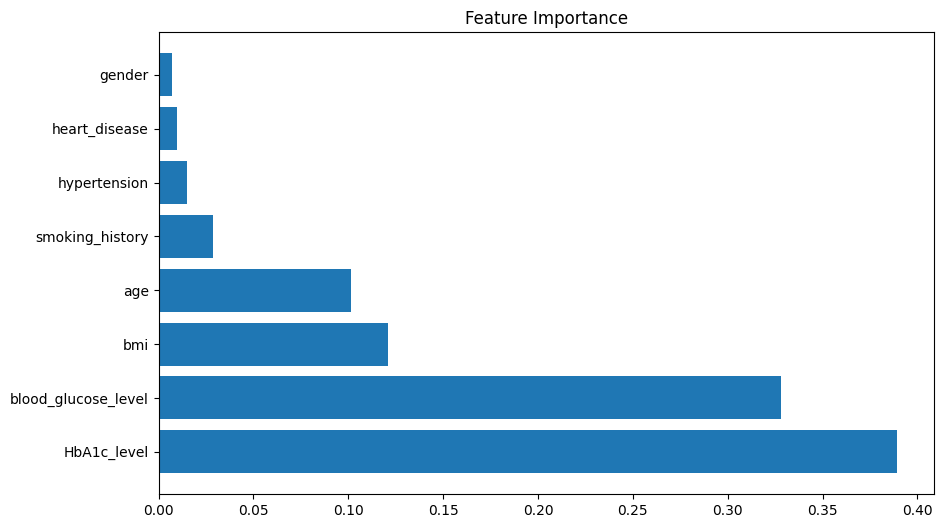

In [25]:
## STEP 15: Feature Importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': importance

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance")

plt.show()


In [26]:
## STEP 16: K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters


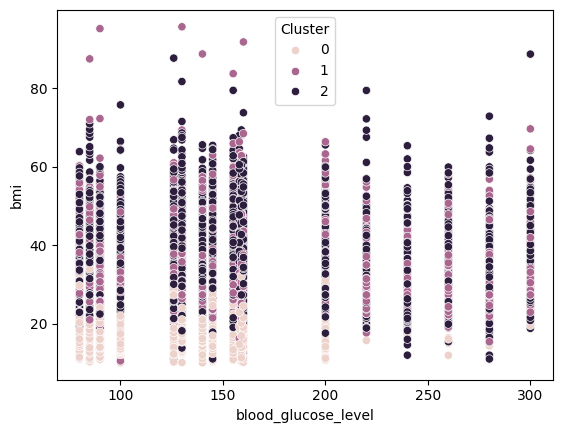

In [27]:
## STEP 17: Cluster Visualization
sns.scatterplot(
    x='blood_glucose_level',
    y='bmi',
    hue='Cluster',
    data=df
)

plt.show()


In [28]:
## STEP 18: Save Model
pickle.dump(
    rf,
    open("best_diabetes_model.pkl", "wb")
)

pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)

print("Model Saved")

Model Saved
